In [1]:
%load_ext autoreload
%autoreload 2

from pprint import pprint
import os, sys
module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import yaml
from dask.distributed import Client, as_completed
import wandb
os.environ["WANDB_SILENT"]="true"

from experiment_board.lr_sparse_identifiability_exps.nyc_taxi_exp import NYCYellowTaxiExperiment # NYCTaxiLR_Sparse_IdStudy, get_data, run_SNN_LOGN_GTV, run_HoRPCA, run_SNN_LOGS, calculate_metrics
# client = Client(n_workers=4, processes=False)
# client

In [2]:
cwd = os.getcwd()
with open(cwd + '/configs/gorpca_nyc_hp_study_bic.yaml') as f:
    config = yaml.safe_load(f)
with open(module_path + '/config.yaml') as f:
    config_main = yaml.safe_load(f)
api_key = config_main['wandb']['api_key']

pprint(config['model_configs']['HoRPCA_1'])
project_name = "nyc_taxi_ad"
group_name = "HoRPCA_real_bic"
tags = ['BIC_initial_search', 'HoRPCA', 'auto']
name_prefix = 'initial'
exp_kwargs = {'notes': f"""Experiment 4: Identifiability Study on NYC Yellow Taxi Dataset,
    Identifiability study to determine the hyper-parameters for the following models:
        - [HoRPCA]
        - [SNN]-[LOGN(S-N)]
        - [SNN]-[LOGN(T-E)]
        - [SNN]-[LOGN(ST-N)]
    """
    }

model_config = config['model_configs']['HoRPCA_1']
exp = NYCYellowTaxiExperiment(project_name=project_name,
                              api_key=api_key,
                              exp_config=model_config,
                              exp_prefix=name_prefix,
                              group_name=group_name,
                              tags=tags)
exp.run_study(80)

{'model': 'HoRPCA',
 'model_control': {'device': 'cuda:0',
                   'err_tol': 1e-06,
                   'lr_modes': [1, 2, 3, 4],
                   'maxit': 150,
                   'mu': 100,
                   'rho': 0.0002,
                   'rho_update': 1,
                   'verbose': 0},
 'name': 'HoRPCA',
 'search_space': {'scheme': 'auto'}}


[I 2025-02-13 06:07:57,125] A new study created in RDB with name: initial_HoRPCA


In [7]:
cwd = os.getcwd()
with open(cwd + '/configs/gorpca_nyc_hp_study_bic.yaml') as f:
    config = yaml.safe_load(f)
with open(module_path + '/config.yaml') as f:
    config_main = yaml.safe_load(f)
api_key = config_main['wandb']['api_key']

pprint(config['model_configs']['SNN_LOGN_SN'])
project_name = "nyc_taxi_ad"
group_name = "SNN_LOGN_SN_num_params_m4"
tags = ['BIC', 'SNN_LOGN_SN', 'auto']
name_prefix = 'm4'
exp_kwargs = {'notes': f"""Experiment 4: Identifiability Study on NYC Yellow Taxi Dataset,
    Identifiability study to determine the hyper-parameters for the following models:
        - [HoRPCA]
        - [SNN]-[LOGN(S-N)]
        - [SNN]-[LOGN(T-E)]
        - [SNN]-[LOGN(ST-N)]
    """
    }

model_config = config['model_configs']['SNN_LOGN_SN']
exp = NYCYellowTaxiExperiment(project_name=project_name,
                              api_key=api_key,
                              exp_config=model_config,
                              exp_prefix=name_prefix,
                              group_name=group_name,
                              tags=tags)
exp.run_study(40)

{'model': 'SNN_LOGN_GTV',
 'model_control': {'device': 'cuda:2',
                   'domain': 'spatial',
                   'err_tol': 1e-06,
                   'graph_modes': [1],
                   'grouping': 'neighbor',
                   'gtvr_config': [],
                   'lda_gtvs': [],
                   'lr_modes': [1, 2, 3, 4],
                   'max_iter': 150,
                   'r_hop': 1,
                   'rho': 0.0002,
                   'rho_update': 1,
                   'rho_update_thr': 100,
                   'verbose': 0,
                   'weighing': 'size_normalized_inv'},
 'name': '[SNN]-[LOGN(S-N)]',
 'search_space': {'scheme': 'auto'}}


[I 2025-02-13 07:57:11,153] Using an existing study with name 'm4_[SNN]-[LOGN(S-N)]' instead of creating a new one.
[I 2025-02-13 07:57:20,391] Trial 80 finished with value: 821388.0 and parameters: {'t_0': 0.202836321916348, 't_1': 0.13089632223998515, 't_2': 0.9062324160377633, 't_3': 0.5595801703926568, 't_4': 0.6658228564324412}. Best is trial 66 with value: 348276.5.
[I 2025-02-13 07:57:26,738] Trial 81 finished with value: 348914.0 and parameters: {'t_0': 0.09793670299082788, 't_1': 0.05900258553795551, 't_2': 0.8045163455634862, 't_3': 0.6139211618769118, 't_4': 0.8215413341423033}. Best is trial 66 with value: 348276.5.
[I 2025-02-13 07:57:32,916] Trial 82 finished with value: 348651.0 and parameters: {'t_0': 0.10410096031744442, 't_1': 0.05785922264948086, 't_2': 0.8082032214359891, 't_3': 0.7261846875872175, 't_4': 0.8219287460587372}. Best is trial 66 with value: 348276.5.
[I 2025-02-13 07:57:39,005] Trial 83 finished with value: 350833.5 and parameters: {'t_0': 0.1603249207

In [2]:
cwd = os.getcwd()
with open(cwd + '/configs/gorpca_nyc_hp_study_bic.yaml') as f:
    config = yaml.safe_load(f)
with open(module_path + '/config.yaml') as f:
    config_main = yaml.safe_load(f)
api_key = config_main['wandb']['api_key']

pprint(config['model_configs']['SNN_LOGN_SN'])
project_name = "nyc_taxi_ad"
group_name = "SNN_LOGN_TE"
tags = ['BIC', 'SNN_LOGN_TE', 'auto']
name_prefix = 'T'
exp_kwargs = {'notes': f"""Experiment 4: Identifiability Study on NYC Yellow Taxi Dataset,
    Identifiability study to determine the hyper-parameters for the following models:
        - [HoRPCA]
        - [SNN]-[LOGN(S-N)]
        - [SNN]-[LOGN(T-E)]
        - [SNN]-[LOGN(ST-N)]
    """
    }

model_config = config['model_configs']['SNN_LOGN_TE']
exp = NYCYellowTaxiExperiment(project_name=project_name,
                              api_key=api_key,
                              exp_config=model_config,
                              exp_prefix=name_prefix,
                              group_name=group_name,
                              tags=tags)
exp.run_study(120)

{'model': 'SNN_LOGN_GTV',
 'model_control': {'device': 'cuda:1',
                   'domain': 'temporal',
                   'err_tol': 1e-06,
                   'graph_modes': [4],
                   'grouping': 'edge',
                   'gtvr_config': [],
                   'lda_gtvs': [],
                   'lr_modes': [1, 2, 3, 4],
                   'max_iter': 150,
                   'r_hop': 1,
                   'rho': 0.0002,
                   'rho_update': 1,
                   'rho_update_thr': 100,
                   'verbose': 0,
                   'weighing': 'size_normalized_inv'},
 'name': '[SNN]-[LOGN(T-E)]',
 'search_space': {'scheme': 'auto'}}


[I 2025-02-13 08:24:23,234] A new study created in RDB with name: TempEdge1_[SNN]-[LOGN(T-E)]
/mnt/ufs18/home-207/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:390: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(B.indptr, B.indices, B.data, device=device, dtype=dtype)
[I 2025-02-13 08:24:30,296] Trial 0 finished with value: 717237.0 and parameters: {'t_0': 0.09428905583479252, 't_1': 0.8454529692551352, 't_2': 0.4652728765752555, 't_3': 0.5086938986940375, 't_4': 0.29339414197233415}. Best is trial 0 with value: 717237.0.
[I 2025-02-13 08:24:36,542] Trial 1 finished with value: 717235.0 and parameters: {'t_0': 0.703873313956382, 't_1': 0.9998724091956899, 't_2': 0.775440

,number,value,datetime_start,datetime_complete,duration,params_t_0,params_t_1,params_t_2,params_t_3,params_t_4,user_attrs_lda,user_attrs_metrics,user_attrs_psi_1,user_attrs_psi_2,user_attrs_psi_3,user_attrs_psi_4,state
0,0,717237.0,2025-02-13 08:24:23.247362,2025-02-13 08:24:30.250670,0 days 00:00:07.003308,0.094289,0.845453,0.465273,0.508694,0.293394,0.235972,"{'Sparsity': 5.546127139418544e-06, 'converged...",0.454415,0.032307,0.147238,0.130069,COMPLETE
1,1,717235.0,2025-02-13 08:24:30.312482,2025-02-13 08:24:36.507598,0 days 00:00:06.195116,0.703873,0.999872,0.775440,0.152343,0.288307,0.333354,"{'Sparsity': 0.0, 'converged': 0, 'iterations'...",0.094120,0.000034,0.068166,0.504326,COMPLETE
2,2,717235.0,2025-02-13 08:24:36.560477,2025-02-13 08:24:42.817107,0 days 00:00:06.256630,0.237359,0.221509,0.681628,0.256977,0.156672,0.283377,"{'Sparsity': 0.0, 'converged': 0, 'iterations'...",0.219868,0.230433,0.058594,0.207727,COMPLETE
3,3,717235.0,2025-02-13 08:24:42.874120,2025-02-13 08:24:49.308052,0 days 00:00:06.433932,0.805493,0.976727,0.370646,0.947183,0.739212,0.190189,"{'Sparsity': 0.0, 'converged': 0, 'iterations'...",0.136142,0.014822,0.624694,0.034154,COMPLETE
4,4,726139.0,2025-02-13 08:24:49.357171,2025-02-13 08:24:55.443705,0 days 00:00:06.086534,0.880058,0.485643,0.046449,0.606339,0.343567,0.194669,"{'Sparsity': 0.0, 'converged': 0, 'iterations'...",0.023281,0.131608,0.559279,0.091163,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,115,346177.5,2025-02-13 08:36:13.043677,2025-02-13 08:36:18.988684,0 days 00:00:05.945007,0.270158,0.196518,0.072635,0.137734,0.940233,0.008107,"{'Sparsity': 0.91935237873393, 'converged': 0,...",0.172156,0.214020,0.344944,0.260774,COMPLETE
116,116,492543.5,2025-02-13 08:36:19.014804,2025-02-13 08:36:24.929415,0 days 00:00:05.914611,0.062729,0.080453,0.179325,0.170479,0.907045,0.010994,"{'Sparsity': 0.8854433574035251, 'converged': ...",0.312017,0.283977,0.193656,0.199356,COMPLETE
117,117,354160.0,2025-02-13 08:36:24.983910,2025-02-13 08:36:30.819635,0 days 00:00:05.835725,0.151572,0.167327,0.356049,0.211903,0.999750,0.000040,"{'Sparsity': 0.9821081938482358, 'converged': ...",0.301434,0.285634,0.164991,0.247901,COMPLETE
118,118,717241.5,2025-02-13 08:36:30.880527,2025-02-13 08:36:36.841484,0 days 00:00:05.960957,0.349886,0.229981,0.031394,0.118025,0.288737,0.132716,"{'Sparsity': 1.8024913203110267e-05, 'converge...",0.112194,0.157023,0.369774,0.228294,COMPLETE


In [3]:
cwd = os.getcwd()
with open(cwd + '/configs/gorpca_nyc_hp_study_bic.yaml') as f:
    config = yaml.safe_load(f)
with open(module_path + '/config.yaml') as f:
    config_main = yaml.safe_load(f)
api_key = config_main['wandb']['api_key']

pprint(config['model_configs']['SNN_LOGN_STN'])
project_name = "nyc_taxi_ad"
group_name = "gtlabel_SNN_LOGN_STN"
tags = ['labels', 'SNN_LOGN_STN', 'auto']
name_prefix = 'label_STempNeighbor'
exp_kwargs = {'notes': f"""Experiment 4: Identifiability Study on NYC Yellow Taxi Dataset,
    Identifiability study to determine the hyper-parameters for the following models:
        - [HoRPCA]
        - [SNN]-[LOGN(S-N)]
        - [SNN]-[LOGN(T-E)]
        - [SNN]-[LOGN(ST-N)]
    """
    }

model_config = config['model_configs']['SNN_LOGN_STN']
exp = NYCYellowTaxiExperiment(project_name=project_name,
                              api_key=api_key,
                              exp_config=model_config,
                              exp_prefix=name_prefix,
                              group_name=group_name,
                              tags=tags)
exp.run_study(120)

[I 2025-02-13 09:25:00,049] Trial 121 finished with value: -100.0 and parameters: {'t_0': 0.9206269129784848, 't_1': 0.15684935481862006, 't_2': 0.4701265994766096, 't_3': 0.9770771360523001, 't_4': 0.7439006866884413}. Best is trial 48 with value: -101.0.
[I 2025-02-13 09:25:06,550] Trial 122 finished with value: -87.0 and parameters: {'t_0': 0.718961149767512, 't_1': 0.0009124283011774439, 't_2': 0.9612434960624291, 't_3': 0.9184660288311446, 't_4': 0.6094395140707743}. Best is trial 48 with value: -101.0.
[I 2025-02-13 09:25:12,918] Trial 123 finished with value: -100.0 and parameters: {'t_0': 0.8106408057181856, 't_1': 0.039698406135510456, 't_2': 0.8838430267953692, 't_3': 0.945827548588502, 't_4': 0.6694535950645243}. Best is trial 48 with value: -101.0.
[I 2025-02-13 09:25:19,392] Trial 124 finished with value: -95.0 and parameters: {'t_0': 0.7715811489947205, 't_1': 0.09823554551181186, 't_2': 0.9770210065243047, 't_3': 0.914982337367839, 't_4': 0.5872668588676646}. Best is tri

,number,value,datetime_start,datetime_complete,duration,params_t_0,params_t_1,params_t_2,params_t_3,params_t_4,user_attrs_lda,user_attrs_metrics,user_attrs_psi_1,user_attrs_psi_2,user_attrs_psi_3,user_attrs_psi_4,state
0,0,NaN,2025-02-13 09:07:19.825268,2025-02-13 09:07:22.955812,0 days 00:00:03.130544,0.540597,0.007091,0.714105,0.291061,0.778920,0.033833,NaN,0.083290,0.670150,0.045597,0.167130,FAIL
1,1,-3.0,2025-02-13 09:08:34.232381,2025-02-13 09:08:41.240213,0 days 00:00:07.007832,0.588160,0.967709,0.723062,0.598159,0.364009,0.418924,"{'Sparsity': 0.0, 'converged': 0, 'iterations'...",0.220019,0.013607,0.134419,0.213031,COMPLETE
2,2,-2.0,2025-02-13 09:08:41.298455,2025-02-13 09:08:47.677419,0 days 00:00:06.378964,0.445496,0.821537,0.758150,0.830184,0.138292,0.574025,"{'Sparsity': 0.0, 'converged': 0, 'iterations'...",0.234604,0.057037,0.080335,0.053999,COMPLETE
3,3,-19.0,2025-02-13 09:08:47.734712,2025-02-13 09:08:54.001454,0 days 00:00:06.266742,0.776631,0.381354,0.346144,0.865601,0.445311,0.250379,"{'Sparsity': 0.001234013288520626, 'converged'...",0.078238,0.298365,0.328347,0.044670,COMPLETE
4,4,-20.0,2025-02-13 09:08:54.053335,2025-02-13 09:09:00.611286,0 days 00:00:06.557951,0.243464,0.407526,0.911696,0.049445,0.250864,0.203580,"{'Sparsity': 0.004918028240879394, 'converged'...",0.207988,0.132151,0.013610,0.442671,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,236,-101.0,2025-02-13 09:37:10.840395,2025-02-13 09:37:17.271961,0 days 00:00:06.431566,0.774118,0.178204,0.647198,0.974524,0.748946,0.105860,"{'Sparsity': 0.25773407429591916, 'converged':...",0.093755,0.631607,0.159329,0.009450,COMPLETE
237,237,-100.0,2025-02-13 09:37:17.323849,2025-02-13 09:37:23.597842,0 days 00:00:06.273993,0.773942,0.241306,0.641403,0.994905,0.761628,0.113483,"{'Sparsity': 0.18809967499694963, 'converged':...",0.106799,0.592506,0.185083,0.002129,COMPLETE
238,238,-101.0,2025-02-13 09:37:23.659737,2025-02-13 09:37:29.845435,0 days 00:00:06.185698,0.789360,0.186399,0.658651,0.999455,0.740175,0.114165,"{'Sparsity': 0.2051678812685102, 'converged': ...",0.089753,0.637430,0.158445,0.000207,COMPLETE
239,239,-101.0,2025-02-13 09:37:29.898503,2025-02-13 09:37:36.258051,0 days 00:00:06.359548,0.761901,0.179540,0.629263,0.979745,0.744173,0.106732,"{'Sparsity': 0.24558112320166828, 'converged':...",0.098228,0.620332,0.167316,0.007392,COMPLETE


In [2]:
cwd = os.getcwd()
with open(cwd + '/configs/nyc_taxi_study.yaml') as f:
    config = yaml.safe_load(f)
with open(module_path + '/config.yaml') as f:
    config_main = yaml.safe_load(f)
api_key = config_main['wandb']['api_key']

client = Client(n_workers=4, processes=False)
client

{'model': 'HoRPCA',
 'name': 'HoRPCA',
 'model_control': {'lr_modes': [1, 2, 3, 4],
  'err_tol': 1e-06,
  'maxit': 150,
  'rho_update': 1,
  'mu': 100,
  'verbose': 0,
  'rho': 0.0002},
 'search_space': {'scheme': 'auto'}}

In [ ]:
project_name = "lr_ss_anomaly_detection"
group_name = "nyc_taxi_id"
data = 'dropoffs'
lr_modes = [[1,2,4]]
tags = ['nyc_taxi_id', f'feature_{data}']
name_prefix = 'nyc_taxi_id_study_Time_graph_' + '_'.join(tags[:-1])
exp_kwargs = {'notes': f"""Experiment 4: Identifiability Study on NYC Yellow Taxi Dataset,
    Identifiability study to determine the hyper-parameters for the following models:
        - [HoRPCA]
        - [SNN]-[LOGN(N)]
        - [SNN]-[LOGN(E)]
    """
    }


In [ ]:
project_name = "lr_ss_anomaly_detection"
group_name = "nyc_taxi_id"
data = 'dropoffs'
lr_modes = [[1,2,4]]
tags = ['nyc_taxi_id', f'feature_{data}']
name_prefix = 'nyc_taxi_id_study_Time_graph_' + '_'.join(tags[:-1])
exp_kwargs = {'notes': f"""Experiment 4: Identifiability Study on NYC Yellow Taxi Dataset,
    Identifiability study to determine the hyper-parameters for the following models:
        - [HoRPCA]
        - [SNN]-[LOGN(N)]
        - [SNN]-[LOGN(E)]
    """
    }

exp = NYCTaxiLR_Sparse_IdStudy(
    project_name=project_name,
    api_key=api_key,
    exp_config=config,
    exp_prefix=name_prefix,
    group_name=group_name,
    tags=tags,
    client=client,
    **exp_kwargs)

exp.run_id_study(lr_modes=lr_modes, data=data)

In [3]:
data = get_data({'data':'dropoffs'})
Y = data['Y']
# model_vars = config['models']['SNN_LOGS_N']
# model_vars['t'] = 0.5
# model_vars['eps'] = 0.01
# model_vars['verbose'] = 2
# model_vars['device'] = 'cuda:2'
# model_vars['max_iter'] = 100
# model_vars['rho'] = 1

# results = run_SNN_LOGS(data, model_vars)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from src.multilinear_ops.matricize import matricize

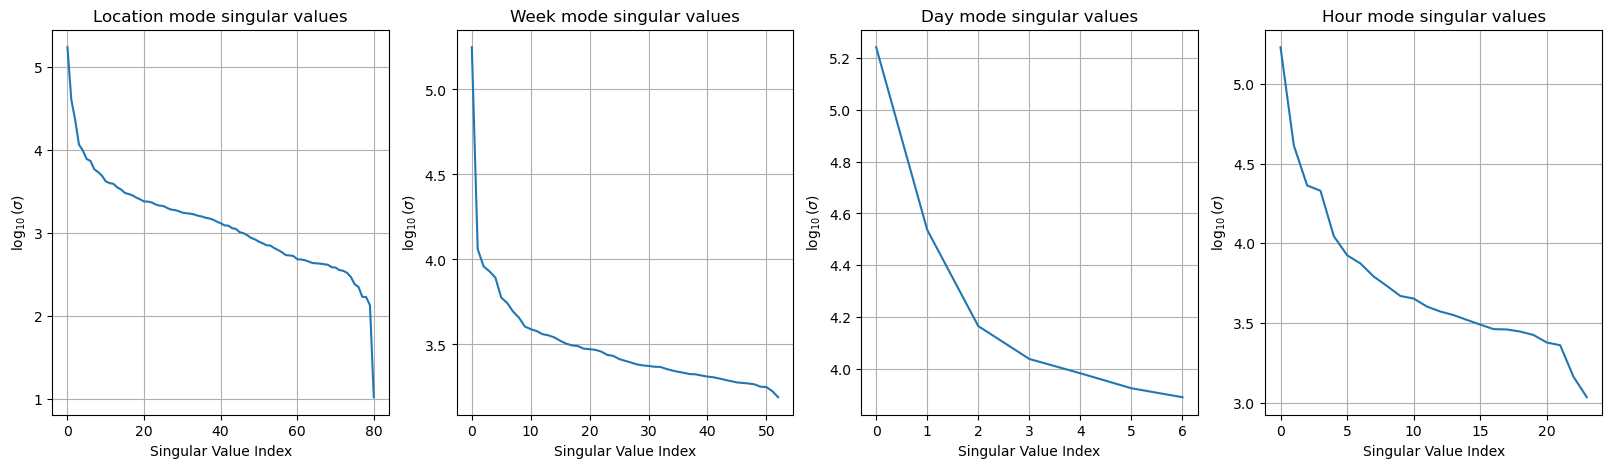

In [20]:
%matplotlib inline
fig, axes = plt.subplots(1,4 , figsize=(20,5))
mode_names = ['Location', 'Week', 'Day', 'Hour']
for m in range(4):
    sv = np.linalg.svd(matricize(Y, [m+1]), compute_uv=False)
    axes[m].plot(np.log10(sv))
    axes[m].set_title(f'{mode_names[m]} mode singular values')
    axes[m].set_xlabel('Singular Value Index')
    axes[m].set_ylabel(r'$\log_{10}(\sigma)$')
    axes[m].grid()

In [8]:
calculate_metrics(results, data)

{'S_diff': 15205.596352210876,
 'L_diff': 15205.840310460439,
 'L1': 33608981.352926955,
 'L1_eps': 28610265.593595818,
 'S1': 59273938.136681214,
 'S1_eps': 64524078.87531641,
 'nonzero_S': 1.0,
 'nonzero_L': 1.0,
 'S_fro': 119948.54503034265,
 'L_fro': 59669.86328339641,
 'L_fro_eps': 49662.154486111715,
 'S_fro_eps': 131578.89091980382,
 'L_nuc_1': 127059.70932445182,
 'S_nuc_1': 255275.84674622043,
 'L_nuc_1_eps': 56750.51438696791,
 'S_nuc_1_eps': 324153.90573675337,
 'ranks_S1': 81,
 'ranks_L1': 81,
 'L_nuc_2': 112441.6472569142,
 'S_nuc_2': 234628.74631153373,
 'L_nuc_2_eps': 51098.3865988413,
 'S_nuc_2_eps': 296457.112318881,
 'ranks_S2': 53,
 'ranks_L2': 53,
 'L_nuc_3': 85319.88629704833,
 'S_nuc_3': 175297.44390530256,
 'L_nuc_3_eps': 60672.92087115691,
 'S_nuc_3_eps': 204083.9929876246,
 'ranks_S3': 7,
 'ranks_L3': 7,
 'L_nuc_4': 112013.40705650664,
 'S_nuc_4': 228743.41087354475,
 'L_nuc_4_eps': 66136.07087670968,
 'S_nuc_4_eps': 277599.465981906,
 'ranks_S4': 24,
 'ranks_L